# Simulation of trading strategy

### Trading Strategy Summary

Simulate a quarterly investment approach driven by Random Forest model predictions (pred_rf):

* Initial capital: $1,000
* Quarterly top-up: $250 (added at the start of each quarter)
* Transaction fee: $1.00 per trade (realistic discount broker rate)
* Buy rule: At the start of a quarter, buy all stocks where pred_rf == True, splitting available capital equally.
* Hold rule: Hold each position until:
    * Stop loss: Price drops 5% from purchase price → sell immediately (at that quarter’s close in simulation).
    * Take profit: Price rises 20% from purchase price → sell immediately.
    * Otherwise, hold until the next quarter’s review.
* Reinvestment: Profits from sales are added to the cash pool and fully reinvested each quarter.
* Fractional shares: Allowed for simplicity.

### Performance Metrics

1. Total Return – final portfolio value vs. starting capital.
2. CAGR (Compound Annual Growth Rate): the annualized growth rate that would take you from your starting value to your ending value if you grew at a constant rate every year. It smooths out volatility to give a long-term growth measure.
3. Max Drawdown – worst peak-to-trough drop.
4. Sharpe Ratio – risk-adjusted return.
5. Win Rate – percentage of trades that made a profit.
6. Number of Trades – total trades executed.

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
notebook_dir = Path().resolve()

# Data folder
data_folder = notebook_dir.parent / "Data"
data_folder.mkdir(exist_ok=True)  # ensures folder exists

In [6]:
rf_model_pred_path = data_folder / "rf_model_pred.csv"
df = pd.read_csv(rf_model_pred_path)

df.shape

(5078, 5)

In [7]:
df

,date,ticker,close,buy_signal,pred_rf
0,2001-12-31,6501.T,666.649902,False,False
1,2001-12-31,6758.T,1004.861816,False,False
2,2001-12-31,7203.T,383.685242,False,False
3,2001-12-31,7267.T,485.978973,False,False
4,2001-12-31,9432.T,22.953232,False,False
...,...,...,...,...,...
5073,2025-09-30,SIE.DE,230.250000,True,True
5074,2025-09-30,UBSG.SW,31.860001,True,True
5075,2025-09-30,ULVR.L,4569.608398,False,False
5076,2025-09-30,UNH,271.809998,False,False


In [16]:
def backtest_fixed_capital(
    df,
    initial_capital=1000,
    transaction_fee=5.0,
    stop_loss_pct=-0.10,
    take_profit_pct=0.30
):
    """
    Backtest a fixed capital strategy where cash is split equally among all predicted buy signals each quarter.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: 'date', 'ticker', 'close', 'pred_rf'
        Sorted by date ascending.
    initial_capital : float
        Starting portfolio value.
    transaction_fee : float
        Fee per buy or sell transaction.
    stop_loss_pct : float
        Stop loss threshold (negative value, e.g., -0.10 = -10%).
    take_profit_pct : float
        Take profit threshold (positive value, e.g., 0.30 = +30%).
    
    Returns
    -------
    portfolio_history : pd.DataFrame
        Portfolio value and cash over time.
    trades : pd.DataFrame
        Record of all executed trades.
    """
    # Ensure sorting
    df = df.sort_values(['date', 'ticker']).reset_index(drop=True)

    # Track portfolio state
    cash = initial_capital
    positions = {}  # ticker -> { 'buy_price': float, 'shares': float, 'buy_date': date }
    portfolio_values = []
    trade_log = []

    for date, group in df.groupby('date'):
        # 1. Check existing positions for stop loss / take profit
        tickers_to_sell = []
        for ticker, pos in positions.items():
            current_price = group.loc[group['ticker'] == ticker, 'close'].values
            if len(current_price) == 0:
                continue
            current_price = current_price[0]
            change_pct = (current_price - pos['buy_price']) / pos['buy_price']

            if change_pct <= stop_loss_pct or change_pct >= take_profit_pct:
                # Sell
                sell_value = pos['shares'] * current_price
                cash += sell_value - transaction_fee
                trade_log.append({
                    'date': date,
                    'ticker': ticker,
                    'type': 'SELL',
                    'price': current_price,
                    'shares': pos['shares'],
                    'value': sell_value
                })
                tickers_to_sell.append(ticker)

        for ticker in tickers_to_sell:
            positions.pop(ticker)

        # 2. Get buy signals for this date
        buy_signals = group[group['pred_rf'] == True]['ticker'].tolist()

        # Exclude tickers we already hold
        buy_signals = [t for t in buy_signals if t not in positions]

        if buy_signals and cash > 0:
            allocation_per_trade = cash / len(buy_signals)

            for ticker in buy_signals:
                price = group.loc[group['ticker'] == ticker, 'close'].values[0]
                shares = (allocation_per_trade - transaction_fee) / price
                if shares <= 0:
                    continue
                positions[ticker] = {
                    'buy_price': price,
                    'shares': shares,
                    'buy_date': date
                }
                trade_log.append({
                    'date': date,
                    'ticker': ticker,
                    'type': 'BUY',
                    'price': price,
                    'shares': shares,
                    'value': shares * price
                })
                cash -= allocation_per_trade

        # 3. Calculate portfolio value
        value_positions = 0
        for ticker, pos in positions.items():
            current_price = group.loc[group['ticker'] == ticker, 'close'].values
            if len(current_price) == 0:
                continue
            value_positions += pos['shares'] * current_price[0]

        portfolio_value = cash + value_positions
        portfolio_values.append({'date': date, 'portfolio_value': portfolio_value, 'cash': cash})

    portfolio_history = pd.DataFrame(portfolio_values)
    trades = pd.DataFrame(trade_log)

    return portfolio_history, trades


In [ ]:
portfolio_history, trades = backtest_fixed_capital(df)

# Final value
final_value = portfolio_history['portfolio_value'].iloc[-1]
print(f"Final portfolio value: ${final_value:,.2f}")

# CAGR
portfolio_history['date'] = pd.to_datetime(portfolio_history['date'])
years = (portfolio_history['date'].iloc[-1] - portfolio_history['date'].iloc[0]).days / 365.25
cagr = (final_value / 1000) ** (1 / years) - 1
print(f"CAGR: {cagr:.2%}")




Final portfolio value: $-89.28
CAGR: nan%
         date ticker type      price    shares       value
0  2001-12-31    BAC  BUY  17.736494  5.982643  106.111111
1  2001-12-31    CAT  BUY  14.443380  7.346695  106.111111
2  2001-12-31    JNJ  BUY  31.259909  3.394479  106.111111
3  2001-12-31     KO  BUY  11.967840  8.866354  106.111111
4  2001-12-31    MMM  BUY  25.602137  4.144619  106.111111


C:\Users\kabal\AppData\Local\Temp\ipykernel_3300\3239910187.py:10: RuntimeWarning: invalid value encountered in scalar power
  cagr = (final_value / 1000) ** (1 / years) - 1


In [12]:
print(f"Final Portfolio Value: ${metrics['final_value']:.2f}")
print(f"Total Return: {metrics['total_return_pct']:.2f}%")
print(f"CAGR: {metrics['cagr']:.2f}%")
print(f"Max Drawdown: {metrics['max_drawdown_pct']:.2f}%")
print(f"Win Rate: {metrics['win_rate_pct']:.2f}%")
print(f"Number of Trades: {metrics['num_trades']}")


Final Portfolio Value: $283.88
Total Return: -71.61%
CAGR: -5.16%
Max Drawdown: -80.40%
Win Rate: 25.81%
Number of Trades: 1046


In [24]:
trades

,date,ticker,type,price,shares,value
0,2001-12-31,BAC,BUY,17.736494,5.982643,106.111111
1,2001-12-31,CAT,BUY,14.443380,7.346695,106.111111
2,2001-12-31,JNJ,BUY,31.259909,3.394479,106.111111
3,2001-12-31,KO,BUY,11.967840,8.866354,106.111111
4,2001-12-31,MMM,BUY,25.602137,4.144619,106.111111
...,...,...,...,...,...,...
251,2008-09-30,LLY,SELL,27.027599,0.300214,8.114053
252,2008-09-30,BP.L,SELL,459.744873,0.011246,5.170154
253,2008-09-30,MMM,SELL,34.229683,0.010765,0.368473
254,2008-09-30,ROG.SW,SELL,97.351646,0.003803,0.370232


In [21]:
portfolio_history

,date,portfolio_value,cash
0,2001-12-31,955.000000,1.421085e-13
1,2002-03-31,984.866916,6.536013e+01
2,2002-06-30,869.601735,-1.598721e-14
3,2002-09-30,682.709095,9.561348e+01
4,2002-12-31,688.090859,9.561348e+01
...,...,...,...
91,2024-09-30,-89.280538,-8.928054e+01
92,2024-12-31,-89.280538,-8.928054e+01
93,2025-03-31,-89.280538,-8.928054e+01
94,2025-06-30,-89.280538,-8.928054e+01


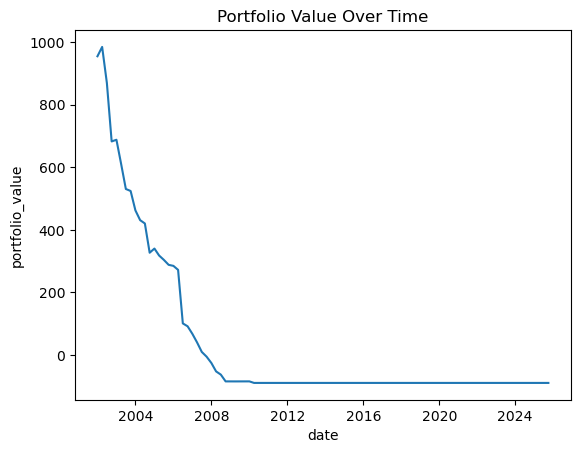

In [23]:
#plt.figure(figsize=(14, 7))
sns.lineplot(data=portfolio_history, x='date', y='portfolio_value')
plt.title('Portfolio Value Over Time')
plt.show()